---
**Title:** DPO — Direct Preference Optimization

**Chapter:** Reinforcement Learning for LLMs

**Difficulty:** Intermediate

**Estimated Time:** 45 min

---

## 1 — Overview

In the previous two notebooks we trained a tiny language model with **REINFORCE** (nb 00) and **PPO** (nb 01). PPO works well, but the pipeline is complex:

- **4 models** in memory simultaneously (actor, critic, reward model, reference)
- A separate reward-model training phase
- Many hyperparameters to tune (clip range, KL coefficient, value-function coefficient, ...)

In 2023, Rafailov et al. showed a surprising shortcut: **we can optimise for human preferences directly, without ever training a reward model.** That method is **Direct Preference Optimization (DPO)**.

| PPO pipeline | DPO pipeline |
|---|---|
| Train reward model → Train value function → Run PPO loop | Collect preference pairs → Run DPO (done) |
| 4 models in memory | **2 models** (policy + reference) |

The rest of this notebook builds DPO from scratch, step by step.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter

from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import draw_rl_algorithm_comparison, draw_training_pipeline
from mp_tutorial.formatting import info_box, comparison_table, formula_breakdown

import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


In [2]:
# -- Our tiny language model (same as notebooks 00 and 01) --
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does -- just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


## 2 — The Complexity Problem

Recall the PPO pipeline from the previous notebook:

1. **Train a reward model** on human preference data
2. **Train a value function** (critic) to estimate expected future reward
3. **Run the PPO loop**: generate → score → compute advantages → update policy (with clipping)

This requires **4 models in GPU memory simultaneously**:

| Model | Role | Trainable? |
|---|---|---|
| Actor (policy) | Generates text | Yes |
| Critic (value function) | Estimates advantages | Yes |
| Reward model | Scores responses | Frozen |
| Reference model | KL anchor | Frozen |

For a 7 B parameter model in fp16, that is roughly 4 × 14 GB = **56 GB** just for weights — before optimizer states, activations, or gradients.

> **What if we could go directly from preference data to a better policy, skipping the reward model entirely?**

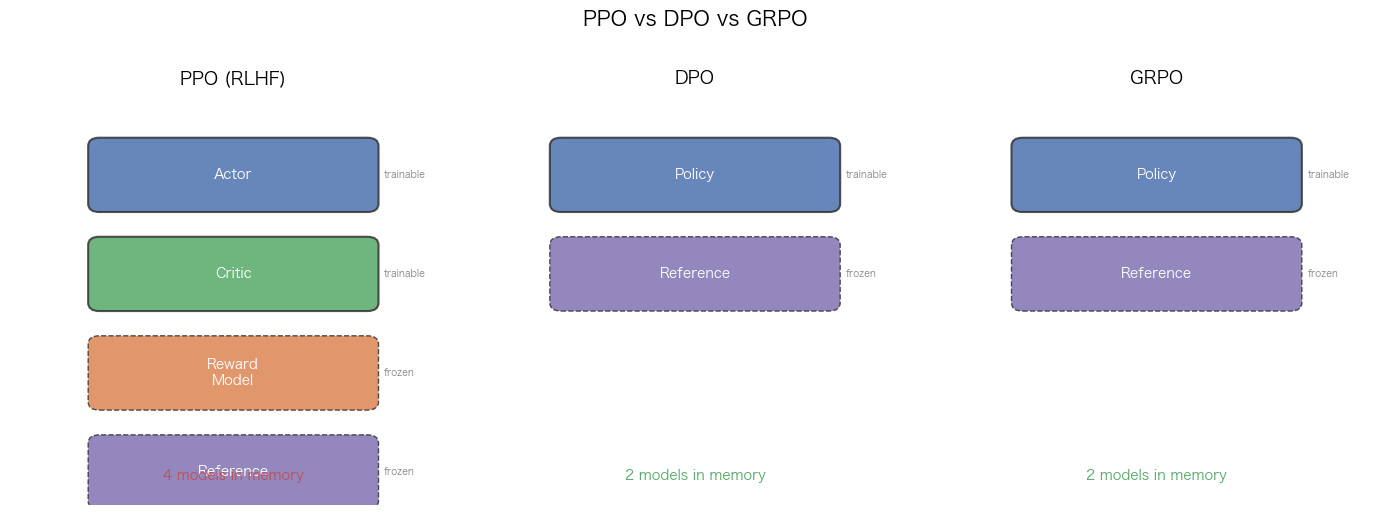

In [3]:
fig, axes = draw_rl_algorithm_comparison()
plt.show()

info_box("DPO replaces PPO's 4-model pipeline with just 2 models. "
         "No reward model, no value function, no multi-phase training loop. "
         "The key: a mathematical shortcut that connects preferences directly to the policy.",
         title="The Simplification")

## 3 — What Are Preference Pairs?

In RLHF we collect **human preferences**: given a prompt, a human annotator looks at two candidate responses and says *"A is better than B"*.

This creates **preference pairs** for each prompt $x$:

$$\bigl(\, y_w ,\; y_l \,\bigr) \quad \text{where } y_w \succ y_l$$

- $y_w$ — the **preferred** (winning) response
- $y_l$ — the **rejected** (losing) response

**Example:**

| Prompt | Preferred ($y_w$) | Rejected ($y_l$) |
|---|---|---|
| *"Tell me about cats"* | *"Cats are fascinating creatures that..."* | *"idk lol cats are whatever"* |

For our toy model, we will construct preference pairs using `reward_fn`: sequences that contain "love" are preferred over sequences that contain "hate".

Preference pairs (preferred > rejected):

  ✓ cats love I          (r=+1.0)   >   ✗ hate dogs I          (r=-0.5)
  ✓ cats love I          (r=+1.0)   >   ✗ I hate dogs          (r=-0.5)
  ✓ cats love I          (r=+1.0)   >   ✗ hate dogs I          (r=-0.5)
  ✓ I love dogs          (r=+0.3)   >   ✗ hate dogs I          (r=-0.5)
  ✓ I love dogs          (r=+0.3)   >   ✗ I hate dogs          (r=-0.5)


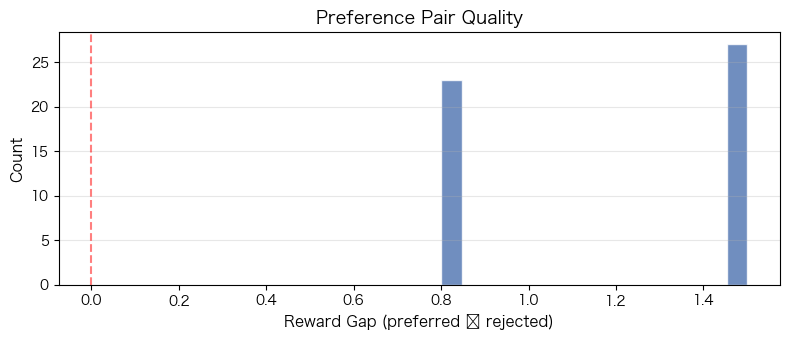

In [4]:
# Create preference pairs from our reward function
torch.manual_seed(42)
n_pairs = 500
preferred, rejected = [], []
for _ in range(n_pairs):
    good = [[0, 1, 2], [0, 1, 4], [2, 1, 0]][np.random.randint(3)]  # love-containing
    bad  = [[0, 3, 2], [0, 3, 4], [3, 4, 0]][np.random.randint(3)]  # hate-containing
    preferred.append(good)
    rejected.append(bad)
preferred_t = torch.tensor(preferred)
rejected_t = torch.tensor(rejected)

# Show some examples
print("Preference pairs (preferred > rejected):\n")
for i in range(5):
    pw = decode(preferred_t[i])
    pl = decode(rejected_t[i])
    rw = reward_fn(preferred_t[i:i+1]).item()
    rl = reward_fn(rejected_t[i:i+1]).item()
    print(f"  \u2713 {pw:20s} (r={rw:+.1f})   >   \u2717 {pl:20s} (r={rl:+.1f})")

# Visualize the preference gap
fig, ax = plt.subplots(figsize=(8, 3.5))
pref_rewards = reward_fn(preferred_t[:50]).numpy()
rej_rewards = reward_fn(rejected_t[:50]).numpy()
gaps = pref_rewards - rej_rewards

ax.hist(gaps, bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
ax.set_xlabel("Reward Gap (preferred \u2212 rejected)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Preference Pair Quality", fontsize=13, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', lw=1.5, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

info_box("Every pair has a clear gap: the preferred output always has a higher reward. "
         "In real RLHF, these comparisons come from human annotators. "
         "DPO learns directly from these pairs \u2014 no need to train a reward model first.",
         title="Preference Pairs")

## 4 — The Bradley-Terry Preference Model

How do we model human preferences mathematically?

The **Bradley-Terry model** says the probability that a human prefers response $A$ over response $B$ is:

$$P(A \succ B) \;=\; \sigma\bigl(r(A) - r(B)\bigr)$$

where $\sigma$ is the **sigmoid function** $\sigma(x) = \frac{1}{1 + e^{-x}}$.

Intuitively:

| Scenario | $r(A) - r(B)$ | $P(A \succ B)$ |
|---|---|---|
| A is much better | $\gg 0$ | $\approx 1$ |
| A and B are equal | $= 0$ | $= 0.5$ (coin flip) |
| B is much better | $\ll 0$ | $\approx 0$ |

In [5]:
info_box("This is the same model used in <b>chess Elo ratings</b>! "
         "If your rating is much higher than your opponent's, you are very likely to win. "
         "If the ratings are close, the outcome is nearly a coin flip.",
         title="Bradley-Terry: Where You Have Seen It Before")

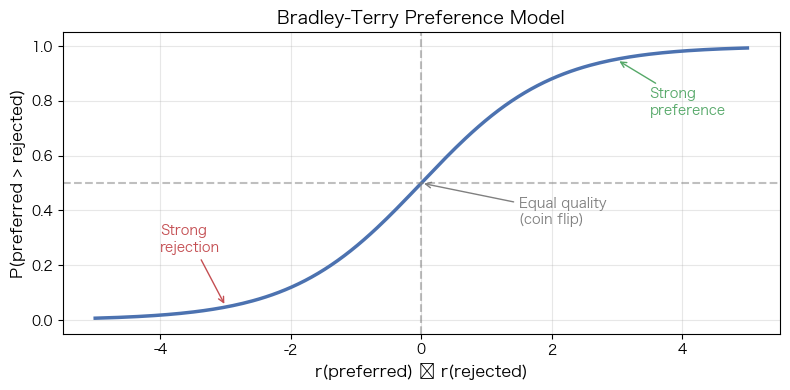

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-5, 5, 200)
y = 1 / (1 + np.exp(-x))
ax.plot(x, y, color='#4C72B0', lw=2.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("r(preferred) \u2212 r(rejected)", fontsize=12)
ax.set_ylabel("P(preferred > rejected)", fontsize=12)
ax.set_title("Bradley-Terry Preference Model", fontsize=13, fontweight='bold')

# Annotate key points
ax.annotate('Equal quality\n(coin flip)', xy=(0, 0.5), xytext=(1.5, 0.35),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
ax.annotate('Strong\npreference', xy=(3, 0.95), xytext=(3.5, 0.75),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#55A868'), color='#55A868')
ax.annotate('Strong\nrejection', xy=(-3, 0.05), xytext=(-4, 0.25),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#C44E52'), color='#C44E52')

ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 5 — The Mathematical Shortcut

This is the key derivation that makes DPO work. We will take it step by step.

### Step 1 — Closed-form optimal policy

The standard RLHF objective is: maximise reward while staying close (in KL divergence) to a reference policy $\pi_{\text{ref}}$. It turns out this objective has a **closed-form solution**:

$$\pi^*(a \mid s) \;=\; \frac{1}{Z(s)}\; \pi_{\text{ref}}(a \mid s) \;\cdot\; \exp\!\left(\frac{1}{\beta}\, r(a, s)\right)$$

where $Z(s)$ is a normalising constant (partition function) and $\beta$ controls how much the policy may deviate from the reference.

### Step 2 — Express reward in terms of policies

Rearrange to solve for $r$:

$$r(a, s) \;=\; \beta \log \frac{\pi^*(a \mid s)}{\pi_{\text{ref}}(a \mid s)} \;+\; \beta \log Z(s)$$

The reward is now written entirely in terms of **policy log-ratios** plus a constant.

### Step 3 — Substitute into Bradley-Terry

Plug the reward expression into the Bradley-Terry preference model. The $Z(s)$ terms **cancel** because both the preferred and rejected responses share the same prompt:

$$\boxed{L_{\text{DPO}} = -\log \sigma\!\left(\, \beta \left[\, \log \frac{\pi_\theta(y_w)}{\pi_{\text{ref}}(y_w)} \;-\; \log \frac{\pi_\theta(y_l)}{\pi_{\text{ref}}(y_l)} \,\right] \right)}$$

**In plain English:** make the model more likely to produce preferred outputs and less likely to produce rejected outputs, *relative to the reference model.*

In [7]:
formula_breakdown([
    (
        "Log-ratio for preferred output \u2014<br>"
        "how much more likely is y<sub>w</sub> under our<br>"
        "policy than under the reference?",
        "log \u03c0<sub>\u03b8</sub>(y<sub>w</sub>) \u2212 log \u03c0<sub>ref</sub>(y<sub>w</sub>)",
        "lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)",
    ),
    (
        "Log-ratio for rejected output \u2014<br>"
        "same comparison for the bad response",
        "log \u03c0<sub>\u03b8</sub>(y<sub>l</sub>) \u2212 log \u03c0<sub>ref</sub>(y<sub>l</sub>)",
        "lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)",
    ),
    (
        "DPO loss \u2014 push the gap between<br>"
        "preferred and rejected log-ratios apart",
        "\u2212log \u03c3(\u03b2 \u00b7 (lp_w \u2212 lp_l))",
        "loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()",
    ),
], title="DPO Loss \u2014 Term by Term")

In Plain English,Math,PyTorch
Log-ratio for preferred output —how much more likely is yw under ourpolicy than under the reference?,log πθ(yw) − log πref(yw),lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)
Log-ratio for rejected output —same comparison for the bad response,log πθ(yl) − log πref(yl),lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)
DPO loss — push the gap betweenpreferred and rejected log-ratios apart,−log σ(β · (lp_w − lp_l)),loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()


## 6 — Implementation

Notice how simple DPO is. The **entire loss** is just three lines of PyTorch:

```python
lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)
lp_l = policy.log_probs_of(rejected)  - ref.log_probs_of(rejected)
loss  = -F.logsigmoid(beta * (lp_w - lp_l)).mean()
```

Compare this to PPO, which needs a clipping mechanism, a value-function head, KL penalty computation, and multiple update epochs per batch. DPO collapses all of that into a single, clean objective.

In [8]:
# ── Train with DPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
beta = 0.1
dpo_losses = []

for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    pref_batch = preferred_t[idx]
    rej_batch = rejected_t[idx]

    # DPO loss (just 3 lines!)
    lp_w = policy.log_probs_of(pref_batch) - ref_model.log_probs_of(pref_batch)
    lp_l = policy.log_probs_of(rej_batch) - ref_model.log_probs_of(rej_batch)
    loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    dpo_losses.append(loss.item())
    if step % 60 == 0:
        print(f"Step {step:3d}  loss = {loss.item():.4f}")

# Check what the DPO-trained model generates
print("\nAfter DPO training:")
seqs = policy.generate(200)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/200:.0%}  reward={r:+.1f}")

Step   0  loss = 0.6931
Step  60  loss = 0.1256
Step 120  loss = 0.0383


Step 180  loss = 0.0211
Step 240  loss = 0.0141

After DPO training:
  I love dogs           freq=51%  reward=+0.3
  I love cats           freq=44%  reward=+1.0
  I love I              freq=4%  reward=+0.3
  I love hate           freq=2%  reward=-0.2


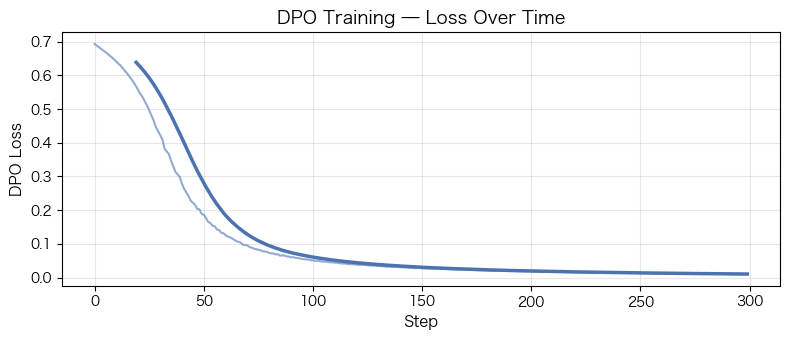

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(dpo_losses, color='#4C72B0', lw=1.5, alpha=0.6)
window = 20
smoothed = np.convolve(dpo_losses, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(dpo_losses)), smoothed, color='#4C72B0', lw=2.5)
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("DPO Loss", fontsize=11)
ax.set_title("DPO Training \u2014 Loss Over Time", fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box("The loss drops smoothly from 0.693 (random, = log 2) to near 0. "
         "This means the model has learned to strongly prefer the good sequences "
         "over the bad ones. No reward model needed!", title="DPO Training")

## 7 — How DPO Updates the Policy

What is DPO actually doing to the model's weights?

For each preference pair $(y_w, y_l)$:

1. DPO **increases** $\log \pi_\theta(y_w)$ — making the preferred output more likely.
2. DPO **decreases** $\log \pi_\theta(y_l)$ — making the rejected output less likely.

But it does this **relative to the reference model**, and that matters:

- If the reference already strongly prefers $y_w$, there is little to learn — DPO barely changes the weights.
- If the reference is **uncertain** between $y_w$ and $y_l$, DPO pushes hard — this is where the model can gain the most.

The reference model acts as an anchor: DPO only "spends effort" where the current model is confused.

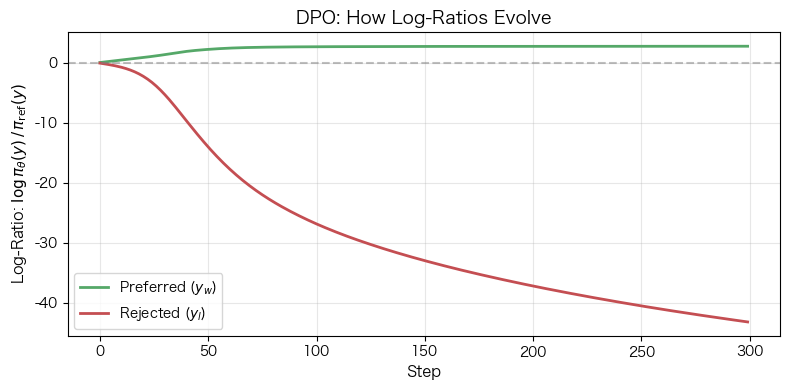

In [10]:
# Track how log-ratios change during training
torch.manual_seed(42)
policy_track = TinyLM()
ref_track = deepcopy(policy_track)
for p in ref_track.parameters():
    p.requires_grad = False
opt_track = torch.optim.Adam(policy_track.parameters(), lr=5e-3)

# Track log-ratios for a fixed batch
fixed_pref = preferred_t[:16]
fixed_rej = rejected_t[:16]

lr_preferred_hist, lr_rejected_hist = [], []
for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    pref_batch = preferred_t[idx]
    rej_batch = rejected_t[idx]
    lp_w = policy_track.log_probs_of(pref_batch) - ref_track.log_probs_of(pref_batch)
    lp_l = policy_track.log_probs_of(rej_batch) - ref_track.log_probs_of(rej_batch)
    loss = -F.logsigmoid(0.1 * (lp_w - lp_l)).mean()
    opt_track.zero_grad()
    loss.backward()
    opt_track.step()

    with torch.no_grad():
        lr_w = (policy_track.log_probs_of(fixed_pref) - ref_track.log_probs_of(fixed_pref)).mean().item()
        lr_l = (policy_track.log_probs_of(fixed_rej) - ref_track.log_probs_of(fixed_rej)).mean().item()
    lr_preferred_hist.append(lr_w)
    lr_rejected_hist.append(lr_l)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lr_preferred_hist, color='#55A868', lw=2, label='Preferred ($y_w$)')
ax.plot(lr_rejected_hist, color='#C44E52', lw=2, label='Rejected ($y_l$)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel(r"Log-Ratio: $\log \pi_\theta(y)\,/\,\pi_{\mathrm{ref}}(y)$", fontsize=11)
ax.set_title("DPO: How Log-Ratios Evolve", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box("Preferred outputs become <b>more likely</b> under the policy (positive log-ratio). "
         "Rejected outputs become <b>less likely</b> (negative log-ratio). "
         "DPO pushes these apart \u2014 that is the optimisation objective.",
         title="Log-Ratio Dynamics")

## 8 — Online vs Offline RL

An important distinction:

- **DPO is offline**: it trains on a **fixed dataset** of preference pairs. The model never generates new data during training.
- **PPO is online**: it generates new data from the *current* policy at every step and learns from that.

This is a fundamental trade-off:

| | Offline (DPO) | Online (PPO) |
|---|---|---|
| **Simplicity** | Very simple | Complex |
| **Stability** | Very stable | Can be unstable |
| **Exploration** | Limited to dataset | Discovers new strategies |
| **Compute** | Cheap (training only) | Expensive (generation + training) |

Offline is simpler and cheaper, but the model can only learn from the strategies that appear in the dataset. Online methods can discover novel strategies that no annotator ever demonstrated.

In [11]:
comparison_table(
    headers=["Property", "Online (PPO)", "Offline (DPO)"],
    rows=[
        ["Data", "Generated by current policy", "Fixed preference dataset"],
        ["Exploration", "Discovers new strategies", "Limited to dataset distribution"],
        ["Complexity", "4 models, multi-phase", "2 models, single-phase"],
        ["Stability", "Can be unstable", "Very stable"],
        ["Compute", "Expensive (generation + training)", "Cheap (training only)"],
    ],
    title="Online vs Offline RL"
)

Property,Online (PPO),Offline (DPO)
Data,Generated by current policy,Fixed preference dataset
Exploration,Discovers new strategies,Limited to dataset distribution
Complexity,"4 models, multi-phase","2 models, single-phase"
Stability,Can be unstable,Very stable
Compute,Expensive (generation + training),Cheap (training only)


## 9 — DPO Variants

DPO's simplicity inspired a family of related algorithms, each addressing a specific limitation:

### IPO — Identity Preference Optimisation

Replaces the log-sigmoid loss with a simpler **squared loss** on the log-ratio gap. This avoids the overfitting problem that DPO can exhibit when training too long on the same preference data.

### KTO — Kahneman-Tversky Optimisation

Does not require preference *pairs* at all — just individual responses labelled "thumbs up" or "thumbs down". This is much cheaper to collect: annotators only judge one response at a time, not compare two.

### cDPO — Conservative DPO

Adds explicit handling for **label noise** in the preference data. If 10 % of your pairs are accidentally swapped (the annotator made a mistake), cDPO degrades gracefully while standard DPO does not.

In [12]:
info_box("DPO spawned a family of algorithms. They all share the core insight: "
         "optimise preferences directly, no reward model. "
         "The differences are in the loss function and the data requirements.",
         title="The DPO Family")

## 10 — DPO vs PPO: Head-to-Head Comparison

Let us train both algorithms on our toy problem and compare the quality of generated sequences over the course of training.

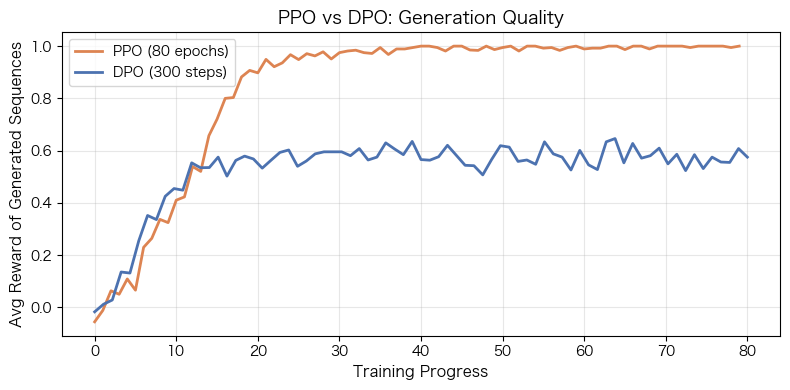

In [13]:
# ── Quick PPO training for comparison ──
torch.manual_seed(42)
ppo_policy = TinyLM()
ppo_ref = deepcopy(ppo_policy)
for p in ppo_ref.parameters():
    p.requires_grad = False
ppo_opt = torch.optim.Adam(ppo_policy.parameters(), lr=3e-3)
ppo_rewards = []

for epoch in range(80):
    seqs = ppo_policy.generate(128)
    rewards = reward_fn(seqs)
    with torch.no_grad():
        old_lp = ppo_policy.log_probs_of(seqs)
        ref_lp = ppo_ref.log_probs_of(seqs)
    advantages = rewards - rewards.mean()
    for _ in range(4):
        new_lp = ppo_policy.log_probs_of(seqs)
        ratio = (new_lp - old_lp).exp()
        s1 = ratio * advantages
        s2 = torch.clamp(ratio, 0.8, 1.2) * advantages
        ppo_loss = -torch.min(s1, s2).mean()
        kl = (new_lp - ref_lp).mean()
        loss = ppo_loss + 0.15 * kl
        ppo_opt.zero_grad()
        loss.backward()
        ppo_opt.step()
    ppo_rewards.append(rewards.mean().item())

# ── DPO training with periodic generation quality evaluation ──
torch.manual_seed(42)
dpo_pol = TinyLM()
dpo_ref2 = deepcopy(dpo_pol)
for p in dpo_ref2.parameters():
    p.requires_grad = False
dpo_opt2 = torch.optim.Adam(dpo_pol.parameters(), lr=5e-3)
dpo_gen_rewards = []

for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    lp_w = dpo_pol.log_probs_of(preferred_t[idx]) - dpo_ref2.log_probs_of(preferred_t[idx])
    lp_l = dpo_pol.log_probs_of(rejected_t[idx]) - dpo_ref2.log_probs_of(rejected_t[idx])
    loss = -F.logsigmoid(0.1 * (lp_w - lp_l)).mean()
    dpo_opt2.zero_grad()
    loss.backward()
    dpo_opt2.step()
    if step % 4 == 0:  # Sample every 4th step to match PPO epochs
        with torch.no_grad():
            gen = dpo_pol.generate(128)
            dpo_gen_rewards.append(reward_fn(gen).mean().item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ppo_rewards, color='#DD8452', lw=2, label='PPO (80 epochs)')
ax.plot(np.linspace(0, 80, len(dpo_gen_rewards)), dpo_gen_rewards,
        color='#4C72B0', lw=2, label='DPO (300 steps)')
ax.set_xlabel("Training Progress", fontsize=11)
ax.set_ylabel("Avg Reward of Generated Sequences", fontsize=11)
ax.set_title("PPO vs DPO: Generation Quality", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11 — The Role of $\beta$

The hyperparameter $\beta$ in the DPO loss controls how far the policy is allowed to deviate from the reference:

$$L_{\text{DPO}} = -\log \sigma\!\left(\, \beta \bigl[\, \text{log-ratio}_w - \text{log-ratio}_l \,\bigr] \right)$$

- **Small $\beta$** (e.g. 0.05): the model can deviate a lot from the reference. Learns faster but risks **mode collapse** — the model may produce only one sequence.
- **Large $\beta$** (e.g. 0.5): the model stays close to the reference. Safer but learns more slowly.
- **Typical values** in practice: $\beta \in [0.1, 0.5]$.

This is analogous to the KL coefficient in PPO — both control the exploration–exploitation trade-off.

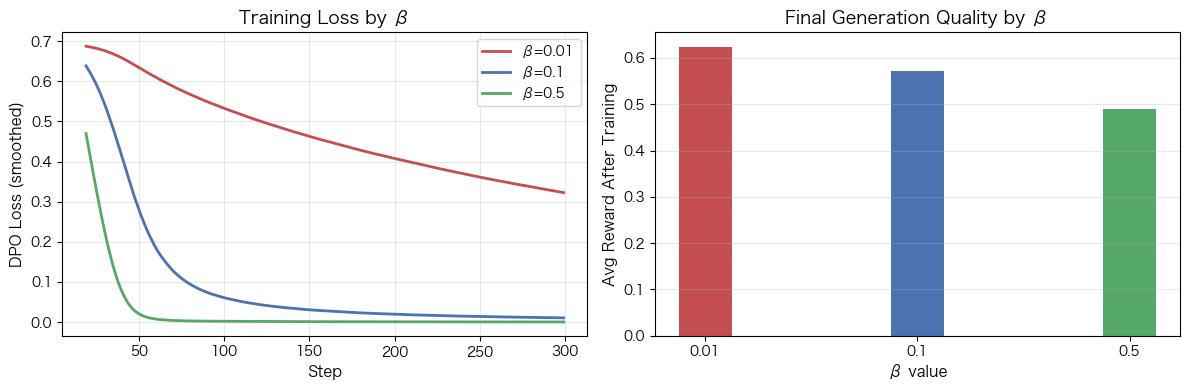

In [14]:
# Sweep over different beta values
betas = [0.01, 0.1, 0.5]
colors = ['#C44E52', '#4C72B0', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for beta_val, color in zip(betas, colors):
    torch.manual_seed(42)
    pol = TinyLM()
    ref = deepcopy(pol)
    for p in ref.parameters():
        p.requires_grad = False
    opt = torch.optim.Adam(pol.parameters(), lr=5e-3)
    losses_b = []
    for step in range(300):
        idx = torch.randint(n_pairs, (64,))
        lp_w = pol.log_probs_of(preferred_t[idx]) - ref.log_probs_of(preferred_t[idx])
        lp_l = pol.log_probs_of(rejected_t[idx]) - ref.log_probs_of(rejected_t[idx])
        loss = -F.logsigmoid(beta_val * (lp_w - lp_l)).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses_b.append(loss.item())

    window = 20
    sm = np.convolve(losses_b, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(losses_b)), sm, color=color, lw=2,
                 label=f'\u03b2={beta_val}')

    # Evaluate generation quality
    with torch.no_grad():
        gen = pol.generate(500)
        r = reward_fn(gen)
    axes[1].bar(betas.index(beta_val), r.mean().item(), color=color, width=0.25,
                label=f'\u03b2={beta_val}')

axes[0].set_xlabel("Step", fontsize=11)
axes[0].set_ylabel("DPO Loss (smoothed)", fontsize=11)
axes[0].set_title("Training Loss by \u03b2", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("\u03b2 value", fontsize=11)
axes[1].set_ylabel("Avg Reward After Training", fontsize=11)
axes[1].set_title("Final Generation Quality by \u03b2", fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(betas)))
axes[1].set_xticklabels([str(b) for b in betas])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

info_box("\u03b2 controls the trade-off between learning speed and stability. "
         "Too small and the model overfits to the preference data; "
         "too large and it barely moves from the reference. "
         "In practice, \u03b2 \u2208 [0.1, 0.5] works well for most tasks.",
         title="Choosing \u03b2")

## Summary

### Key Takeaways

1. **DPO eliminates the reward model** by optimising preferences directly — a mathematical shortcut from the closed-form optimal policy through Bradley-Terry to the DPO loss.
2. The loss is **just 3 lines of PyTorch**: compute log-ratios for preferred and rejected, then push the gap through a log-sigmoid.
3. **2 models instead of 4** — half the GPU memory compared to PPO.
4. **Offline training**: simple and stable, but no exploration of new strategies.
5. **$\beta$** controls how far the policy may deviate from the reference (analogous to the KL coefficient in PPO).
6. DPO spawned a **family of variants**: IPO (squared loss), KTO (no pairs needed), cDPO (noise-robust).

### The Evolution So Far

| Notebook | Algorithm | Key Idea |
|---|---|---|
| 00 | REINFORCE | Policy gradient — increase probability of high-reward outputs |
| 01 | PPO | Clipped objective + KL penalty for stable updates |
| **02** | **DPO** | **Skip the reward model — optimise preferences directly** |
| 03 | GRPO | Skip the critic too — group-relative advantages (next!) |

In [15]:
info_box("DPO removed the reward model. But can we go even simpler? "
         "<b>GRPO</b> (used by DeepSeek-R1) removes the value function too \u2014 "
         "and works online. Next notebook!",
         title="What\u2019s Next")